# 프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!


- `load_diabetes`에서 데이터를 가져옵니다.
- `data`를 `df_X`에, `target`을 `df_y`에 저장합니다.
---

In [ ]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

- `df_X`를 numpy array(넘파이 배열)로 변환합니다.
---

In [ ]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


- `df_y`를 numpy array(넘파이 배열)로 변환합니다.
---


In [ ]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


* 트레인 데이터와 테스트 데이터로 분리한다.
---

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)



- feature(특성) 개수에 맞는 가중치 `W`와 `b`를 준비합니다.
- 같은 결과를 재현하기 위해 random seed(난수 시드)를 고정합니다.
---

In [ ]:
np.random.seed(42)

W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10



* 입력 데이터 개수에 맞는 가중치 W와 b를 준비해주세요.
* 모델 함수를 구현해주세요.
---

In [ ]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

- 손실함수를 MSE(평균제곱오차)로 정의합니다.
---

In [ ]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [ ]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L


- `W`와 `b`가 loss를 줄이는 방향을 계산합니다.
---

In [ ]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

#### * 학습률와 학습 반복 횟수를 설정합니다.
---
** MSE를 줄이기 위해 학습 횟수를 늘려야함 **  
** 러닝레이트 0.001은 너무 세밀한 것으로 생각되어 0.01로 조정함 **   
"우리는 간단한 실험을 할 예정이니 학습률을 적당히 1로 설정하고 시작해 보겠습니다. 사실 복잡한 데이터셋에서는 보통 학습률을 0.0001 ~ 0.01 정도의 작은 값으로 사용합니다."  
** MSE가 3,000이하가 나올 때까지 range를 늘리면서 반복 실행을 진행함. **


In [ ]:
LEARNING_RATE = 0.1


In [ ]:

global W, b

losses = []

for i in range(1, 15001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5376.4189
Iteration 200 : Loss 4874.7584
Iteration 300 : Loss 4501.7302
Iteration 400 : Loss 4220.6626
Iteration 500 : Loss 4005.7570
Iteration 600 : Loss 3838.8200
Iteration 700 : Loss 3706.9816
Iteration 800 : Loss 3601.1027
Iteration 900 : Loss 3514.6625
Iteration 1000 : Loss 3442.9812
Iteration 1100 : Loss 3382.6761
Iteration 1200 : Loss 3331.2810
Iteration 1300 : Loss 3286.9801
Iteration 1400 : Loss 3248.4206
Iteration 1500 : Loss 3214.5813
Iteration 1600 : Loss 3184.6804
Iteration 1700 : Loss 3158.1096
Iteration 1800 : Loss 3134.3884
Iteration 1900 : Loss 3113.1308
Iteration 2000 : Loss 3094.0216
Iteration 2100 : Loss 3076.8002
Iteration 2200 : Loss 3061.2473
Iteration 2300 : Loss 3047.1768
Iteration 2400 : Loss 3034.4286
Iteration 2500 : Loss 3022.8639
Iteration 2600 : Loss 3012.3615
Iteration 2700 : Loss 3002.8145
Iteration 2800 : Loss 2994.1286
Iteration 2900 : Loss 2986.2199
Iteration 3000 : Loss 2979.0136
Iteration 3100 : Loss 2972.4427
Iteration 3200 : 

In [ ]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2884.0030078359937)

In [ ]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)

print(f"Test MSE: {mse:,.3f}")
print("루브릭 통과:", mse <= 3000)
mse

Test MSE: 2,884.003
루브릭 통과: True


np.float64(2884.0030078359937)

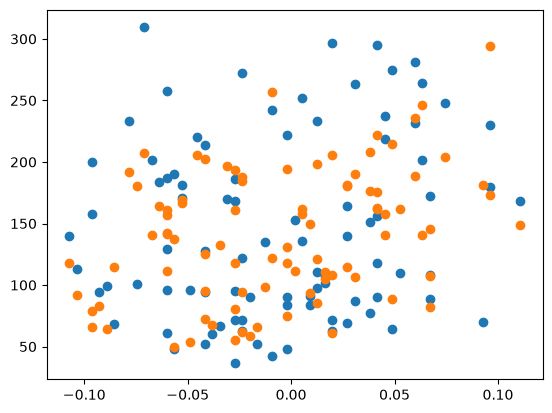

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

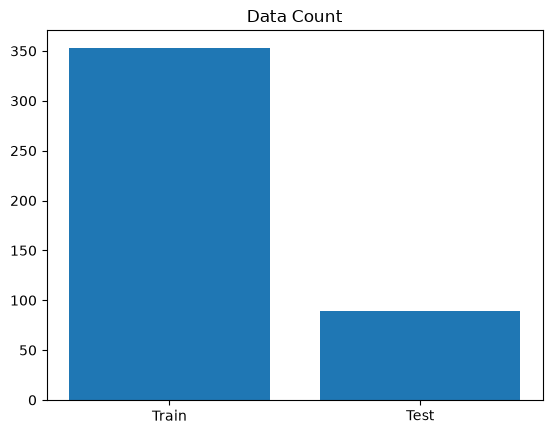

In [ ]:
plt.bar(
    ["Train", "Test"],
    [len(X_train), len(X_test)]
)

plt.title("Data Count")
plt.show()

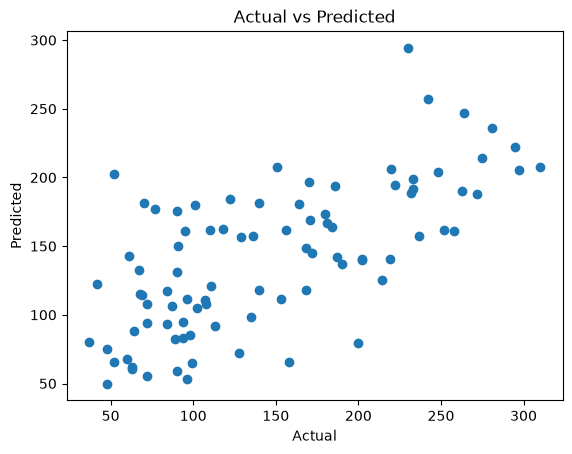

In [ ]:
plt.scatter(y_test, prediction)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?


구글 드라이브에서 데이터 다운로드  
- 데이터: 10,886개  
- 목표: 자전거 대여량 예측  

In [ ]:
import gdown
import pandas as pd

gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)
train = pd.read_csv("train.csv") 
train.info()

Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: /Users/yongza/300억/PRI_AI/AIFFEL_Self_Study/notebooks/train.csv
100%|██████████| 648k/648k [00:00<00:00, 2.36MB/s]

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


#### 시간을 연·월·일·시 등으로 분리.  
- 문자열 상태의 날짜 데이터를 변환.  
---

In [ ]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-null  int32

#### 연도, 월, 일, 시간별로 데이터가 몇 개씩 존재하는지 시각화
---

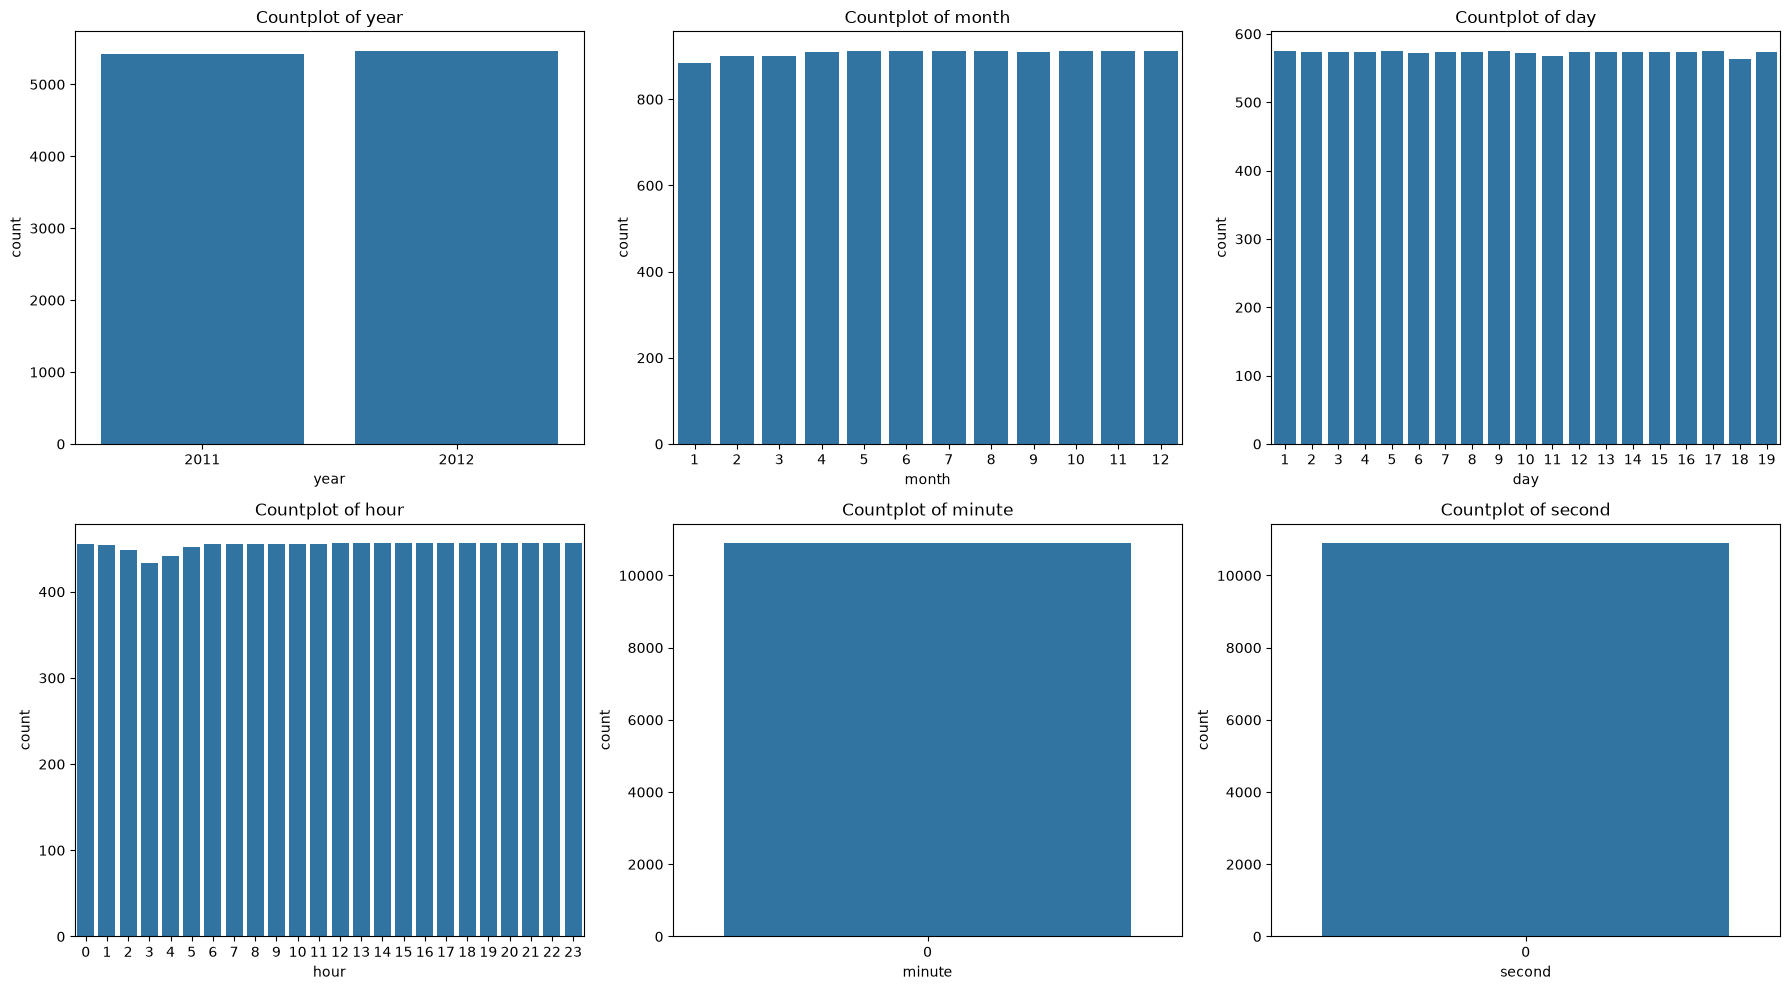

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

#### 데이터 분리하기

- X: 모델이 참고할 조건  
- y: 모델이 맞혀야 하는 자전거 대여량  
---
#### 학습·시험 데이터 분리하기 
- 80%: 모델 학습  
- 20%: 처음 보는 데이터로 성능 평가  
- random_state=42는 random seed(난수 시드)를 고정  
---
### hour 원핫 인코딩  
- 시간을 숫자가 아니라 범주화 진행 (MSE 개선 시도)  
- pd.get_dummies() 판다스 함수를 사용해서 

In [ ]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = pd.get_dummies(train[features], columns=['hour'])
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 회귀모델 학습하기

- Linear Regression(선형회귀)이 각 특성과 자전거 대여량 사이의 관계를 학습  
- LinearRegression은 linear regression(선형회귀) 모델을 만들어주는 scikit-learn의 클래스  
---

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[ 84.82, 6.93, 0.37,...,-17.01,-50.82,-89.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['year','month','day',...,'hour_21','hour_22','hour_23']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.705e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(29)


#### 모델 예측값 출력 및 손실함수값 계산  
mse = mean_squared_error(y_test, y_pred)  
- y_test: 실제 대여량  
- y_pred: 모델이 예측한 대여량  
---

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 10640.45788099929
RMSE: 103.15259512488909


#### 예측 결과 시각화

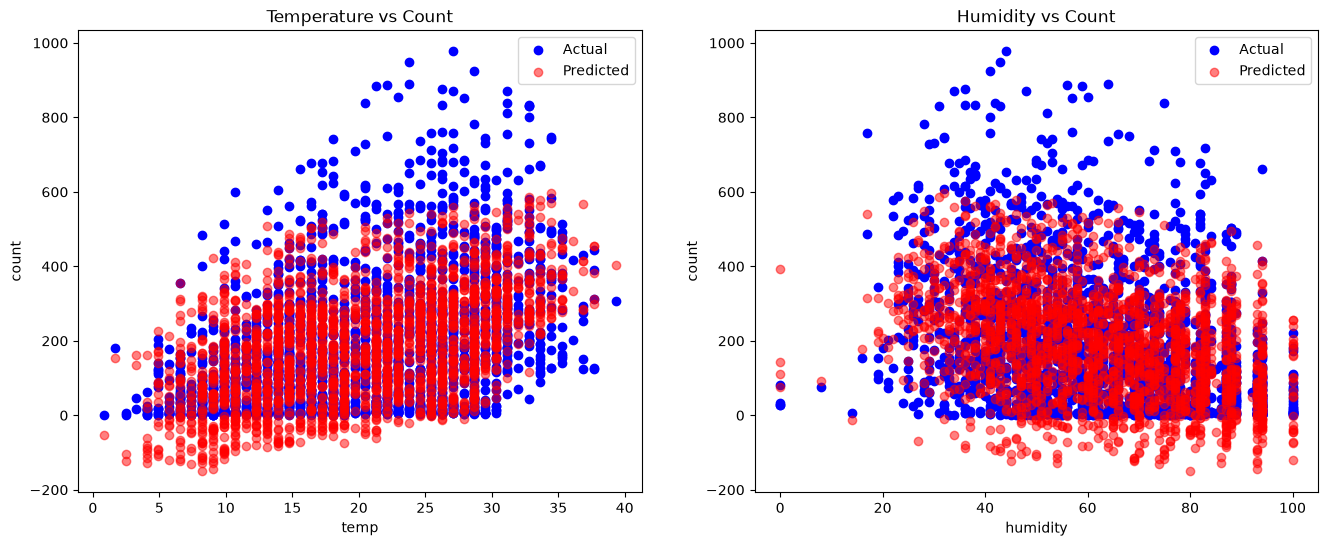

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()